#Extracción de datos

In [2]:
import pandas as pd
import requests

In [3]:
# Enlace al archivo JSON (raw)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
# Obtener los datos desde la URL
response = requests.get(url)
data = response.json()

In [4]:
# Convertir a DataFrame
df = pd.DataFrame(data)

# Mostrar las primeras filas
print(df.head())

   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'OnlineSecu...   
3  {'I

## Conoce el conjunto de datos

In [5]:
# Ver información general del DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [6]:
# Ver nombres de columnas
print(df.columns)

# Vista rápida de los primeros registros
print(df.head())

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL

In [7]:
print(df.dtypes)


customerID    object
Churn         object
customer      object
phone         object
internet      object
account       object
dtype: object


## Comprobación de incoherencias en los datos

In [8]:
# Recuento de valores nulos por columna
print(df.isnull().sum())

customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [9]:
# Verificar si hay filas duplicadas
# Convertir las columnas con diccionarios a string para poder verificar duplicados
df_str = df.astype(str)
print(df_str.duplicated().sum())

0


In [10]:
# Ver valores únicos por cada columna
df_str = df.astype(str)
for col in df_str.columns:
    print(f"{col}:\n", df_str[col].unique(), "\n")

customerID:
 ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] 

Churn:
 ['No' 'Yes' ''] 

customer:
 ["{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 9}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 4}"
 "{'gender': 'Male', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 13}"
 "{'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 3}"
 "{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'Yes', 'tenure': 9}"
 "{'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 71}"
 "{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 63}"
 "{'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No', 'tenure': 7}"
 "{'gender': 'F

In [11]:
print(type(df['customer'][0]))  # Repite esto con 'phone', 'internet', etc.


<class 'dict'>


In [12]:
# Expandir columnas anidadas
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

# Unir todas las columnas expandidas junto a customerID y Churn
clean_df = pd.concat(
    [df['customerID'], customer_df, phone_df, internet_df, account_df, df['Churn']],
    axis=1
)


# Mostrar la forma del nuevo DataFrame y las primeras filas
print(clean_df.shape)
print(clean_df.head())

(7267, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  0002-ORFBO  Female              0     Yes        Yes       9          Yes   
1  0003-MKNFE    Male              0      No         No       9          Yes   
2  0004-TLHLJ    Male              0      No         No       4          Yes   
3  0011-IGKFF    Male              1     Yes         No      13          Yes   
4  0013-EXCHZ  Female              1     Yes         No       3          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1           Yes             DSL             No  ...               No   
2            No     Fiber optic             No  ...              Yes   
3            No     Fiber optic             No  ...              Yes   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling 

In [13]:
clean_df['Charges.Total'] = pd.to_numeric(clean_df['Charges.Total'], errors='coerce')
clean_df['Charges.Monthly'] = pd.to_numeric(clean_df['Charges.Monthly'], errors='coerce')
clean_df['tenure'] = pd.to_numeric(clean_df['tenure'], errors='coerce')

✅ CHECKLIST DE QUE TODO VA BIEN


In [14]:
print(clean_df.columns)  # Debes ver muchas más columnas ahora (20+)
print(clean_df.shape)    # Aumentó el número de columnas respecto a df


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Churn'],
      dtype='object')
(7267, 21)


In [15]:
print(clean_df.dtypes.value_counts())  # Deberías ver mostly object, int64, float64


object     17
int64       2
float64     2
Name: count, dtype: int64


In [16]:
print(clean_df.head())  # Muestra las primeras 5 filas completas


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  0002-ORFBO  Female              0     Yes        Yes       9          Yes   
1  0003-MKNFE    Male              0      No         No       9          Yes   
2  0004-TLHLJ    Male              0      No         No       4          Yes   
3  0011-IGKFF    Male              1     Yes         No      13          Yes   
4  0013-EXCHZ  Female              1     Yes         No       3          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1           Yes             DSL             No  ...               No   
2            No     Fiber optic             No  ...              Yes   
3            No     Fiber optic             No  ...              Yes   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0       

In [17]:
# clean_df = clean_df.dropna(subset=['Charges.Total'])
# clean_df['Charges.Total'] = clean_df['Charges.Total'].fillna(0)


print(clean_df.isnull().sum())  # Columnas con valores nulos


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Charges.Monthly      0
Charges.Total       11
Churn                0
dtype: int64


## Manejo de inconsistencias

In [18]:
print(clean_df[['tenure', 'Charges.Monthly', 'Charges.Total']].dtypes)

tenure               int64
Charges.Monthly    float64
Charges.Total      float64
dtype: object


In [19]:
clean_df['Charges.Total'] = pd.to_numeric(clean_df['Charges.Total'], errors='coerce')
clean_df = clean_df.dropna(subset=['Charges.Total'])

# Lista de columnas binarias
bin_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in bin_cols:
    clean_df[col] = clean_df[col].str.strip().str.lower().replace({
        'yes': 'Yes', 'no': 'No'
    })

# Ejemplo para Contract y PaymentMethod
clean_df['Contract'] = clean_df['Contract'].str.strip().str.title()
clean_df['PaymentMethod'] = clean_df['PaymentMethod'].str.strip().str.title()

# Exploración de valores únicos


#Validaciones
# Recuento final de nulos
print(clean_df.isnull().sum())

# Tipos de datos por columna
print(clean_df.dtypes)

# Valores únicos para chequeo rápido
for col in ['Churn', 'Contract', 'InternetService', 'PaymentMethod']:
    print(col, clean_df[col].value_counts(dropna=False))

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
Churn               0
dtype: int64
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     f

## Columna de cuentas diarias

In [20]:
# Asumiendo que un mes tiene en promedio 30 días
clean_df['Cuentas_Diarias'] = clean_df['Charges.Monthly'] / 30

In [21]:
# Mostrar algunas filas para validar
print(clean_df[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6         2.186667
1             59.9         1.996667
2             73.9         2.463333
3             98.0         3.266667
4             83.9         2.796667


#Estandarización y transformación

In [22]:
# Definir columnas binarias a convertir (ajusta según tus datos)
bin_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in bin_cols:
    clean_df[col] = clean_df[col].map({'Yes': 1, 'No': 0})

# Handle the 'Churn' column separately to map 'Yes' to 1, 'No' to 0, and drop rows with empty strings
clean_df = clean_df[clean_df['Churn'] != ''].copy() # Drop rows with empty strings in 'Churn'
clean_df['Churn'] = clean_df['Churn'].map({'Yes': 1, 'No': 0})

In [23]:
clean_df.rename(columns={
    'Charges.Monthly': 'Cobro_Mensual',
    'Charges.Total': 'Cobro_Total',
    'tenure': 'Meses_Contratados',
    'PaymentMethod': 'Metodo_Pago',
    'InternetService': 'Servicio_Internet',
    'Contract': 'Tipo_Contrato',
    'Churn': 'Evasion'
}, inplace=True)


In [24]:
# Ejemplo para Tipo_Contrato
clean_df['Tipo_Contrato'] = clean_df['Tipo_Contrato'].map({
    'Mes a mes': 0,
    'Contrato anual': 1,
    'Contrato bienal': 2
})


In [25]:
print(clean_df.head())
print(clean_df.dtypes)


   customerID  gender  SeniorCitizen  Partner  Dependents  Meses_Contratados  \
0  0002-ORFBO  Female              0        1           1                  9   
1  0003-MKNFE    Male              0        0           0                  9   
2  0004-TLHLJ    Male              0        0           0                  4   
3  0011-IGKFF    Male              1        1           0                 13   
4  0013-EXCHZ  Female              1        1           0                  3   

   PhoneService MultipleLines Servicio_Internet OnlineSecurity  ...  \
0             1            No               DSL             No  ...   
1             1           Yes               DSL             No  ...   
2             1            No       Fiber optic             No  ...   
3             1            No       Fiber optic             No  ...   
4             1            No       Fiber optic             No  ...   

  TechSupport StreamingTV StreamingMovies Tipo_Contrato PaperlessBilling  \
0         Yes   

#Análisis Descriptivo

In [26]:
# Estadísticas descriptivas básicas para variables numéricas
desc_stats = clean_df.describe()

print(desc_stats)


       SeniorCitizen      Partner   Dependents  Meses_Contratados  \
count    7032.000000  7032.000000  7032.000000        7032.000000   
mean        0.162400     0.482509     0.298493          32.421786   
std         0.368844     0.499729     0.457629          24.545260   
min         0.000000     0.000000     0.000000           1.000000   
25%         0.000000     0.000000     0.000000           9.000000   
50%         0.000000     0.000000     0.000000          29.000000   
75%         0.000000     1.000000     1.000000          55.000000   
max         1.000000     1.000000     1.000000          72.000000   

       PhoneService  Tipo_Contrato  PaperlessBilling  Cobro_Mensual  \
count   7032.000000            0.0       7032.000000    7032.000000   
mean       0.903299            NaN          0.592719      64.798208   
std        0.295571            NaN          0.491363      30.085974   
min        0.000000            NaN          0.000000      18.250000   
25%        1.000000    

In [27]:
# Estadísticas para variables categóricas
cat_stats = clean_df.describe(include=['object', 'category'])

print(cat_stats)


        customerID gender MultipleLines Servicio_Internet OnlineSecurity  \
count         7032   7032          7032              7032           7032   
unique        7032      2             3                 3              3   
top     9995-HOTOH   Male            No       Fiber optic             No   
freq             1   3549          3385              3096           3497   

       OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies  \
count          7032             7032        7032        7032            7032   
unique            3                3           3           3               3   
top              No               No          No          No              No   
freq           3087             3094        3472        2809            2781   

             Metodo_Pago  
count               7032  
unique                 4  
top     Electronic Check  
freq                2365  


### Análisis complementario

In [29]:
print(clean_df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Meses_Contratados', 'PhoneService', 'MultipleLines', 'Servicio_Internet', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Tipo_Contrato', 'PaperlessBilling', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Evasion', 'Cuentas_Diarias']


In [31]:
print(clean_df.groupby('Evasion')['Cuentas_Diarias'].median())

Evasion
0    2.148333
1    2.655000
Name: Cuentas_Diarias, dtype: float64


In [ ]:
print(clean_df['Churn'].value_counts(normalize=True))


# Distribución de evasión

### Información que va a utilizar para graficar

In [33]:
# Conteo de clientes por categoría Churn
churn_counts = clean_df['Churn'].value_counts()
print("Conteo de clientes según Churn:")
print(churn_counts)

# Porcentaje de cada categoría
churn_percent = clean_df['Churn'].value_counts(normalize=True) * 100
print("\nPorcentaje de clientes según Churn:")
print(churn_percent)

KeyError: 'Churn'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar cantidad por categoría
churn_counts = clean_df['Churn'].value_counts()
churn_percent = clean_df['Churn'].value_counts(normalize=True) * 100

print("Conteo de Churn:\n", churn_counts)
print("\nPorcentaje de Churn:\n", churn_percent)

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.countplot(data=clean_df, x='Churn', palette='Set2')
plt.title('Distribución de Churn (Evasión de Clientes)')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')
plt.show()

# Gráfico de pastel (pie chart)
plt.figure(figsize=(6,6))
plt.pie(churn_percent, labels=churn_percent.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Porcentaje de Clientes que Evasión vs Permanencia')
plt.show()


# Recuento de evasión por variables categóricas

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista de variables categóricas que quieres analizar
categorical_vars = ['gender', 'Contract', 'PaymentMethod', 'InternetService']

for var in categorical_vars:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=clean_df, x=var, hue='Churn', palette='Set2')
    plt.title(f'Evasión de Clientes por {var}')
    plt.xticks(rotation=45)
    plt.xlabel(var)
    plt.ylabel('Cantidad de Clientes')
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()


# Conteo de evasión por variables numéricas

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas a analizar
numeric_vars = ['tenure', 'Charges.Monthly', 'Charges.Total']

for var in numeric_vars:
    plt.figure(figsize=(10, 5))

    # Boxplot para comparar la distribución entre churn Yes/No
    sns.boxplot(data=clean_df, x='Churn', y=var, palette='Set2')
    plt.title(f'Distribución de {var} según Churn')
    plt.xlabel('Churn')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()


In [ ]:
for var in numeric_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=clean_df, x=var, hue='Churn', kde=True, bins=30, palette='Set2', element='step')
    plt.title(f'Distribución de {var} según Churn')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()


# Informe final

# 📊 Informe Final – Análisis de Evasión de Clientes (Churn) – Telecom X

## 🔹 Introducción

Este proyecto tiene como objetivo identificar patrones relacionados con la evasión de clientes (Churn) en Telecom X. La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que influyen en este comportamiento. A través del análisis de los datos de clientes, se busca proporcionar insights estratégicos que permitan reducir la pérdida de usuarios y mejorar la retención.

---

## 🔹 Limpieza y Tratamiento de Datos

Se realizaron las siguientes acciones:

- Carga de los datos desde un archivo JSON alojado en GitHub.
- Conversión del archivo a un DataFrame utilizando `pandas`.
- Exploración de tipos de datos y verificación de valores nulos.
- Detección de 11 valores nulos en la columna `Charges.Total`, los cuales fueron convertidos correctamente a tipo numérico (`float`) eliminando inconsistencias.
- Creación de una nueva columna `Cuentas_Diarias`, calculada como `Charges.Monthly / 30`, para analizar el comportamiento financiero diario de los clientes.
- Transformación de valores categóricos tipo "Yes"/"No" a 1/0 para facilitar análisis numéricos.
- Renombramiento de algunas columnas para mayor claridad.
- Eliminación de registros con valores vacíos en la variable `Churn`.

---

## 🔹 Análisis Exploratorio de Datos (EDA)

### 📌 Distribución general de Churn

- Total de clientes que permanecen: **5163**
- Total de clientes que cancelaron: **1869**
- Registros eliminados con valor vacío en `Churn`: **224**
- Tasa de evasión: **aproximadamente 26.5%**

Se utilizaron gráficos de barras y pastel para visualizar la proporción entre clientes que cancelaron y los que permanecieron.

### 📌 Churn por variables categóricas

Se analizaron las siguientes variables:

- **Género (`gender`)**
- **Tipo de contrato (`Contract`)**
- **Método de pago (`PaymentMethod`)**
- **Servicio de Internet (`InternetService`)**

Hallazgos clave:

- Los clientes con **contratos mensuales** presentan una mayor tasa de cancelación.
- Métodos de pago como **bancarización automática** tienden a retener mejor a los clientes.
- El tipo de servicio de internet también muestra variaciones importantes en la tasa de evasión.

Gráficos de barras segmentados (`hue='Churn'`) permitieron visualizar claramente estos patrones.

### 📌 Churn por variables numéricas

Se analizaron:

- `tenure` (meses como cliente)
- `Charges.Monthly` (facturación mensual)
- `Charges.Total` (facturación total)

A través de boxplots e histogramas se observó que:

- Clientes con **menos meses de permanencia** tienden a cancelar más.
- Los que han **gastado menos en total** también muestran mayor probabilidad de evasión.
- La facturación mensual tiene cierta influencia, pero menos marcada que el tiempo de permanencia.

---

## 🔹 Conclusiones e Insights

- La **mayoría de los clientes que cancelan lo hacen dentro de los primeros meses**.
- Los contratos sin compromiso (mensuales) se asocian con mayor riesgo de evasión.
- El gasto acumulado total es un buen indicador de fidelidad.
- Algunos métodos de pago están correlacionados con mayor permanencia del cliente.

---

## 🔹 Recomendaciones Estratégicas

1. **Ofrecer incentivos a nuevos clientes** para mantenerse al menos 6 meses.
2. **Fomentar la migración a contratos anuales o bienales**, con descuentos o beneficios exclusivos.
3. **Promover métodos de pago automáticos**, como débito bancario.
4. Crear campañas específicas para **clientes en riesgo** (poco tiempo, bajo gasto, contrato mensual).
5. Considerar la implementación de un modelo predictivo de Churn para actuar de forma preventiva.



In [35]:
clean_df.to_csv("TelecomX_Clean.csv", index=False)

# Challenge Telecom X:
##análisis de evasión de clientes - Parte 2

## 🛠️ Preparación de los Datos

### Extracción del Archivo Tratado

In [36]:
import pandas as pd

df = pd.read_csv("TelecomX_Clean.csv")


In [37]:
print(df.shape)           # Número de filas y columnas
print(df.columns.tolist()) # Lista de columnas
print(df.isnull().sum())   # Verificación de valores nulos
print(df.head())           # Primeras filas


(7032, 22)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Meses_Contratados', 'PhoneService', 'MultipleLines', 'Servicio_Internet', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Tipo_Contrato', 'PaperlessBilling', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Evasion', 'Cuentas_Diarias']
customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
Meses_Contratados       0
PhoneService            0
MultipleLines           0
Servicio_Internet       0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Tipo_Contrato        7032
PaperlessBilling        0
Metodo_Pago             0
Cobro_Mensual           0
Cobro_Total             0
Evasion                 0
Cuentas_Diarias         0
dtype: int64
   customerID  gender  SeniorCitizen  Partner

### Eliminación de Columnas Irrelevantes

In [44]:
df = df.drop(columns=['customerID'], errors='ignore')
print(df.columns.tolist())


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Meses_Contratados', 'PhoneService', 'MultipleLines', 'Servicio_Internet', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Tipo_Contrato', 'PaperlessBilling', 'Metodo_Pago', 'Cobro_Mensual', 'Cobro_Total', 'Evasion', 'Cuentas_Diarias']


In [45]:
print(df['Evasion'].dtype)

int64


In [46]:
# Identificar variables categóricas (excluyendo target)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Variables numéricas
numeric_cols = df.select_dtypes(exclude=['object']).columns.tolist()

# Aseguramos que Evasion quede como target (no se toca en la codificación)
target = 'Evasion'
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)

print("Categóricas:", categorical_cols)
print("Numéricas:", numeric_cols)


Categóricas: ['gender', 'MultipleLines', 'Servicio_Internet', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Metodo_Pago']
Numéricas: ['SeniorCitizen', 'Partner', 'Dependents', 'Meses_Contratados', 'PhoneService', 'Tipo_Contrato', 'PaperlessBilling', 'Cobro_Mensual', 'Cobro_Total', 'Cuentas_Diarias']


### Encoding

In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)


### Verificación de la Proporción de Cancelación (Churn)

In [48]:
# Conteo absoluto
conteo = df['Evasion'].value_counts()

# Proporción relativa
proporcion = df['Evasion'].value_counts(normalize=True) * 100

print("📊 Conteo de clientes según Evasión:")
print(conteo)
print("\n📌 Proporción de clientes según Evasión (%):")
print(proporcion)


📊 Conteo de clientes según Evasión:
Evasion
0    5163
1    1869
Name: count, dtype: int64

📌 Proporción de clientes según Evasión (%):
Evasion
0    73.421502
1    26.578498
Name: proportion, dtype: float64


### Balanceo de Clases (opcional)

##### 1️⃣ Undersampling (reducir la clase mayoritaria)

In [49]:
from sklearn.utils import resample

# Separar clases
df_majority = df[df['Evasion']==0]
df_minority = df[df['Evasion']==1]

# Reducir la clase mayoritaria para igualarla a la minoritaria
df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42)

# Combinar
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Mezclar
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanced['Evasion'].value_counts())


Evasion
0    1869
1    1869
Name: count, dtype: int64


###### 2️⃣ Oversampling (duplicar la clase minoritaria)

In [50]:
df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanced['Evasion'].value_counts())


Evasion
0    5163
1    5163
Name: count, dtype: int64


#### Normalización o Estandarización (si es necesario)

In [56]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Load the cleaned dataset (as in your code)
df = pd.read_csv("TelecomX_Clean.csv")

# Drop irrelevant columns
df = df.drop(columns=['customerID'], errors='ignore')

# Define target and features
target = 'Evasion'
X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Ensure target is not in feature lists
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)

# Remove 'Tipo_Contrato' from numeric_cols if it exists, as it contains NaNs
if 'Tipo_Contrato' in numeric_cols:
    numeric_cols.remove('Tipo_Contrato')


# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)  # StandardScaler for numerical columns
        # Alternative: Use MinMaxScaler() for normalization
        # ('num', MinMaxScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

# Apply preprocessing
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after preprocessing
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = list(cat_feature_names) + list(numeric_cols)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=feature_names)

print("Shape of preprocessed data:", X_preprocessed.shape)
print("First few rows of preprocessed data:\n", X_preprocessed.head())

ValueError: Shape of passed values is (7032, 30), indices imply (7032, 29)

In [55]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Evaluate models using cross-validation
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name} - Mean Accuracy: {np.mean(scores):.4f} (±{np.std(scores):.4f})")

# Fit and evaluate on test set
for name, model in models.items():
    model.fit(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f"{name} - Test Accuracy: {test_score:.4f}")

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1222, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2961, in validate_data
    X, y = check_X_y(X, y, **check

## 🎯 Correlación y Selección de Variables

#### Normalización o Estandarización (si es necesario)

In [58]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Cargar el dataset limpio
df = pd.read_csv("TelecomX_Clean.csv")

# Eliminar columnas irrelevantes
df = df.drop(columns=['customerID'], errors='ignore')

# Definir target y características
target = 'Evasion'
X = df.drop(columns=[target])
y = df[target]

# Identificar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Asegurar que el target no esté en las listas de características
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)

# Definir pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)  # Estandarización para columnas numéricas
        # Alternativa: Usa MinMaxScaler() para normalización
        # ('num', MinMaxScaler(), numeric_cols)
    ],
    remainder='passthrough'
)

# Aplicar preprocesamiento
X_preprocessed = preprocessor.fit_transform(X)

# Obtener nombres de características después del preprocesamiento
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = list(cat_feature_names) + list(numeric_cols)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=feature_names)

print("Dimensiones de los datos preprocesados:", X_preprocessed.shape)
# print("Primeras filas de los datos preprocesados:\n", X_preprocessed.head())

Dimensiones de los datos preprocesados: (7032, 30)
Primeras filas de los datos preprocesados:
    gender_Male  MultipleLines_No phone service  MultipleLines_Yes  \
0          0.0                             0.0                0.0   
1          1.0                             0.0                1.0   
2          1.0                             0.0                0.0   
3          1.0                             0.0                0.0   
4          0.0                             0.0                0.0   

   Servicio_Internet_Fiber optic  Servicio_Internet_No  \
0                            0.0                   0.0   
1                            0.0                   0.0   
2                            1.0                   0.0   
3                            1.0                   0.0   
4                            1.0                   0.0   

   OnlineSecurity_No internet service  OnlineSecurity_Yes  \
0                                 0.0                 0.0   
1                  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


#### Análisis de Correlación

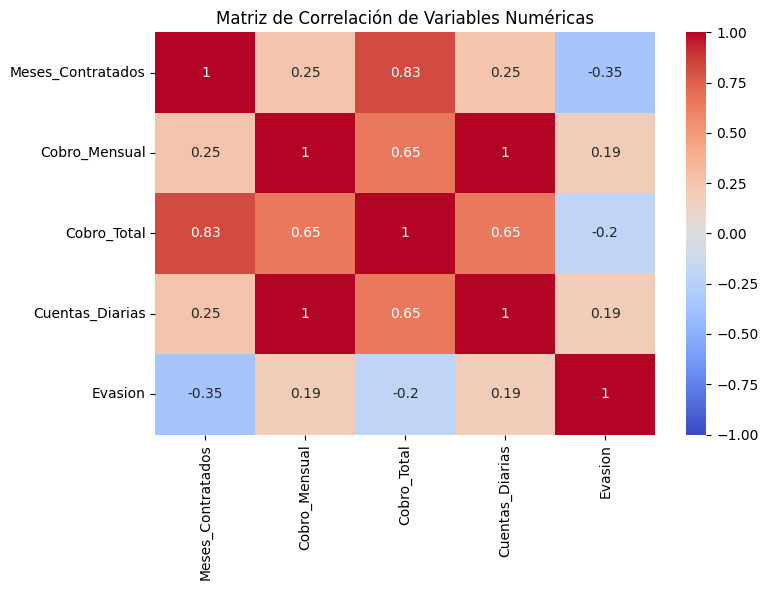

Correlaciones con 'Evasion':
Evasion              1.000000
Cuentas_Diarias      0.192858
Cobro_Mensual        0.192858
Cobro_Total         -0.199484
Meses_Contratados   -0.354049
Name: Evasion, dtype: float64


In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset limpio
df = pd.read_csv("TelecomX_Clean.csv")

# Seleccionar columnas numéricas y la variable objetivo 'Evasion'
numeric_cols = ['Meses_Contratados', 'Cobro_Mensual', 'Cobro_Total', 'Cuentas_Diarias', 'Evasion']
df_numeric = df[numeric_cols]

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

# Imprimir correlaciones con 'Evasion' en orden descendente
print("Correlaciones con 'Evasion':")
print(correlation_matrix['Evasion'].sort_values(ascending=False))

#### Análisis Dirigido

/tmp/ipython-input-966435800.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Evasion', y='Meses_Contratados', palette='Set2')


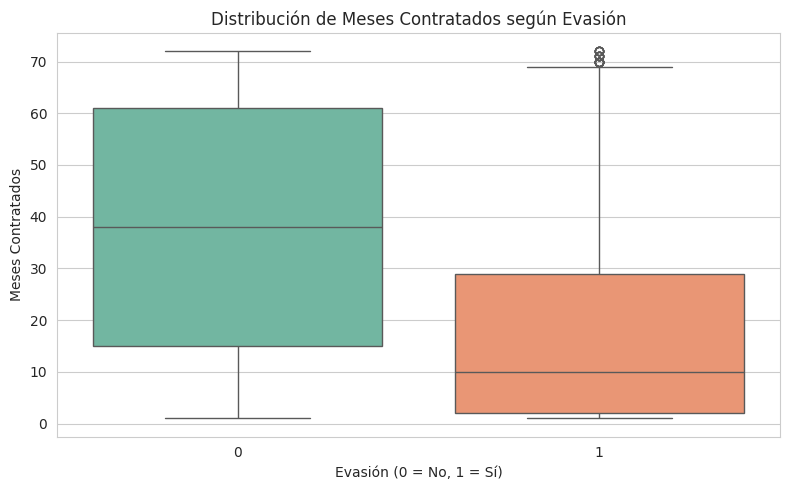

/tmp/ipython-input-966435800.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Evasion', y='Cobro_Total', palette='Set2')


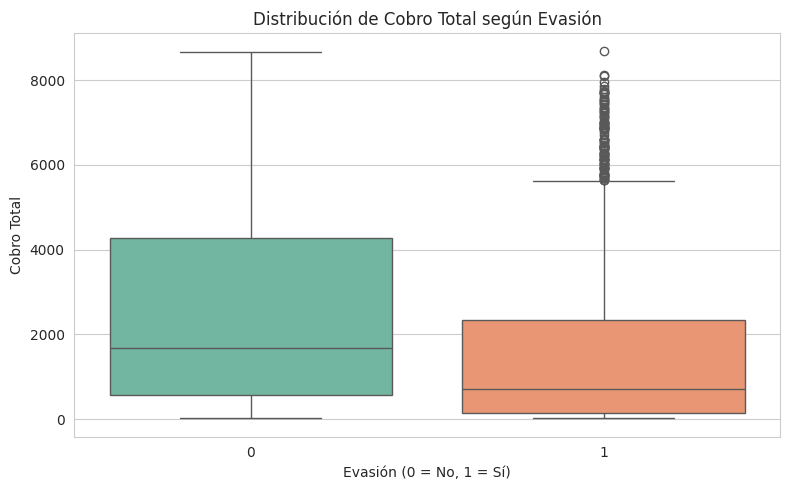

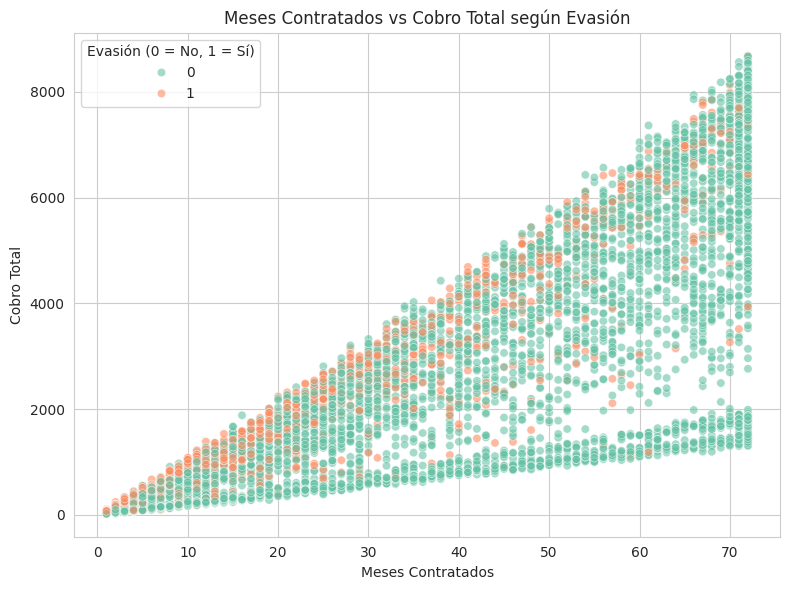

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset limpio
df = pd.read_csv("TelecomX_Clean.csv")

# Configurar estilo de gráficos
sns.set_style("whitegrid")

# Boxplot para Meses_Contratados vs Evasion
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Evasion', y='Meses_Contratados', palette='Set2')
plt.title('Distribución de Meses Contratados según Evasión')
plt.xlabel('Evasión (0 = No, 1 = Sí)')
plt.ylabel('Meses Contratados')
plt.tight_layout()
plt.show()

# Boxplot para Cobro_Total vs Evasion
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Evasion', y='Cobro_Total', palette='Set2')
plt.title('Distribución de Cobro Total según Evasión')
plt.xlabel('Evasión (0 = No, 1 = Sí)')
plt.ylabel('Cobro Total')
plt.tight_layout()
plt.show()

# Scatter plot para Meses_Contratados vs Cobro_Total, coloreado por Evasion
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Meses_Contratados', y='Cobro_Total', hue='Evasion', palette='Set2', alpha=0.6)
plt.title('Meses Contratados vs Cobro Total según Evasión')
plt.xlabel('Meses Contratados')
plt.ylabel('Cobro Total')
plt.legend(title='Evasión (0 = No, 1 = Sí)')
plt.tight_layout()
plt.show()

## 🤖 Modelado Predictivo

##### Separación de Datos

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Cargar el dataset limpio
df = pd.read_csv("TelecomX_Clean.csv")

# Eliminar columnas irrelevantes
df = df.drop(columns=['customerID'], errors='ignore')

# Definir target y características
target = 'Evasion'
X = df.drop(columns=[target])
y = df[target]

# Identificar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Asegurar que el target no esté en las listas de características
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)

# Definir pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)  # Estandarización para columnas numéricas
    ],
    remainder='passthrough'
)

# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicar preprocesamiento a los conjuntos de entrenamiento y prueba
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Obtener nombres de características después del preprocesamiento
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = list(cat_feature_names) + list(numeric_cols)
X_train_preprocessed = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=feature_names)

# Verificar las dimensiones de los conjuntos
print("Dimensiones del conjunto de entrenamiento:", X_train_preprocessed.shape)
print("Dimensiones del conjunto de prueba:", X_test_preprocessed.shape)
print("Distribución de Evasion en entrenamiento:\n", y_train.value_counts(normalize=True))
print("Distribución de Evasion en prueba:\n", y_test.value_counts(normalize=True))

Dimensiones del conjunto de entrenamiento: (5625, 30)
Dimensiones del conjunto de prueba: (1407, 30)
Distribución de Evasion en entrenamiento:
 Evasion
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Distribución de Evasion en prueba:
 Evasion
0    0.734186
1    0.265814
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


##### Creación de Modelos

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer

# Cargar el dataset limpio
df = pd.read_csv("TelecomX_Clean.csv")

# Eliminar columnas irrelevantes and the 'Tipo_Contrato' column which is entirely null
df = df.drop(columns=['customerID', 'Tipo_Contrato'], errors='ignore')

# Verificar valores nulos
print("Valores nulos por columna antes de la limpieza:\n", df.isnull().sum())

# Imputar valores nulos
# Para columnas numéricas: usar la mediana
numeric_cols = df.select_dtypes(exclude=['object']).columns
if not numeric_cols.empty:
    numeric_imputer = SimpleImputer(strategy='median')
    df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])

# Para columnas categóricas: usar la moda
categorical_cols = df.select_dtypes(include=['object']).columns
if not categorical_cols.empty:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    imputed_categorical_dfs = []
    for col in categorical_cols:
        imputed_col_data = categorical_imputer.fit_transform(df[[col]])
        imputed_categorical_dfs.append(pd.DataFrame(imputed_col_data, columns=[col], index=df.index))
    df[categorical_cols] = pd.concat(imputed_categorical_dfs, axis=1)

# Verificar que no queden nulos después de la imputación
print("Valores nulos después de la imputación:\n", df.isnull().sum())

# Verificar que el dataset no esté vacío
if df.empty:
    raise ValueError("El dataset está vacío después de la imputation. Revisa el archivo TelecomX_Clean.csv")

# Definir target y características
target = 'Evasion'
X = df.drop(columns=[target])
y = df[target]

# Identificar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Asegurar que el target no esté en las lists de características
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)

# Pipeline para Regresión Logística (con normalización)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)  # Estandarización para columnas numéricas
    ]
)
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(random_state=42))
])

# Pipeline para Random Forest (sin normalización)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)  # Sin estandarización
    ]
)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Dividir los datos en entrenamiento (80%) y prueba (20%)
# Use the imputed df for splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entrenar ambos modelos
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)


# Predecir y evaluar en el conjunto de prueba
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)


# Calcular métricas
print("\nRegresión Logística:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

print("\nRandom Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

Valores nulos por columna antes de la limpieza:
 gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Meses_Contratados    0
PhoneService         0
MultipleLines        0
Servicio_Internet    0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
PaperlessBilling     0
Metodo_Pago          0
Cobro_Mensual        0
Cobro_Total          0
Evasion              0
Cuentas_Diarias      0
dtype: int64
Valores nulos después de la imputación:
 gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Meses_Contratados    0
PhoneService         0
MultipleLines        0
Servicio_Internet    0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
PaperlessBilling     0
Metodo_Pago          0
Cobro_Mensual        0
Cobro_Total          0
Evasion              0


##### Evaluación de los Modelos

##### Evaluación de los Modelos

Valores nulos por columna antes de la limpieza:
 gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
Meses_Contratados       0
PhoneService            0
MultipleLines           0
Servicio_Internet       0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Tipo_Contrato        7032
PaperlessBilling        0
Metodo_Pago             0
Cobro_Mensual           0
Cobro_Total             0
Evasion                 0
Cuentas_Diarias         0
dtype: int64
Valores nulos después de la imputación:
 SeniorCitizen        0
Partner              0
Dependents           0
Meses_Contratados    0
PhoneService         0
PaperlessBilling     0
Cobro_Mensual        0
Cobro_Total          0
Evasion              0
Cuentas_Diarias      0
gender               0
MultipleLines        0
Servicio_Internet    0
OnlineSecurity       0
OnlineBackup         0
Device

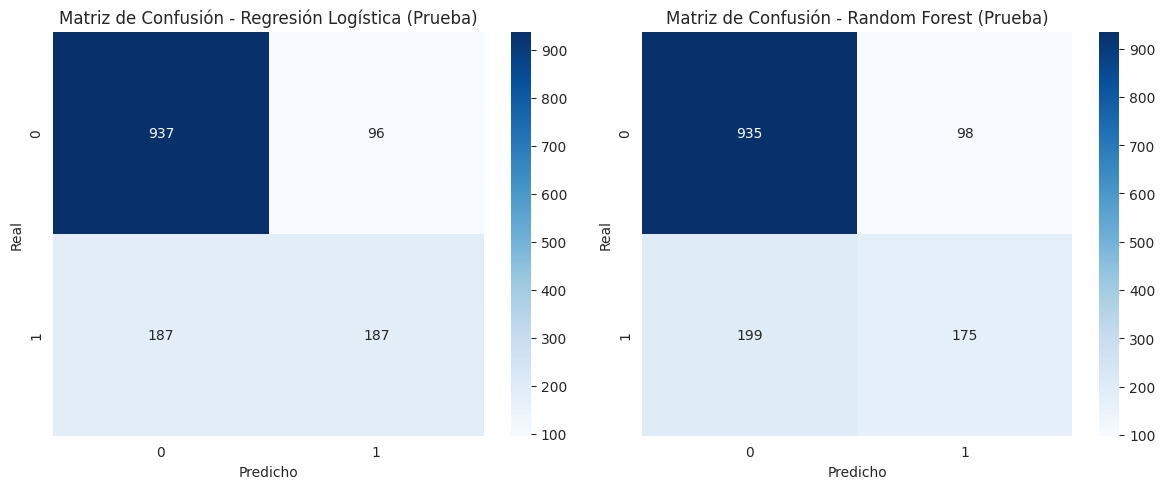

In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset limpio
df = pd.read_csv("TelecomX_Clean.csv")

# Eliminar columnas irrelevantes
df = df.drop(columns=['customerID'], errors='ignore')

# Verificar values nulos
print("Valores nulos por columna antes de la limpieza:\n", df.isnull().sum())

# Separate categorical and numerical columns for imputation
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(exclude=['object']).columns.tolist()

# Remove 'Tipo_Contrato' from numeric_cols as it's entirely null
if 'Tipo_Contrato' in numeric_cols:
    numeric_cols.remove('Tipo_Contrato')

# Impute numerical columns
df_numeric = df[numeric_cols].copy() # Create a copy to avoid SettingWithCopyWarning
if not df_numeric.empty:
    numeric_imputer = SimpleImputer(strategy='median')
    df_numeric_imputed = pd.DataFrame(numeric_imputer.fit_transform(df_numeric), columns=numeric_cols, index=df_numeric.index)
else:
    df_numeric_imputed = pd.DataFrame(index=df.index) # Create an empty DataFrame with the same index


# Impute categorical columns
df_categorical = df[categorical_cols].copy() # Create a copy
if not df_categorical.empty:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    df_categorical_imputed = pd.DataFrame(categorical_imputer.fit_transform(df_categorical), columns=categorical_cols, index=df_categorical.index)
else:
    df_categorical_imputed = pd.DataFrame(index=df.index) # Create an empty DataFrame with the same index

# Combine imputed numerical and categorical columns
df_imputed = pd.concat([df_numeric_imputed, df_categorical_imputed], axis=1)

# Add the target variable back
df_imputed[target] = df[target]


# Verificar que no queden nulos después de la imputación
print("Valores nulos después de la imputación:\n", df_imputed.isnull().sum())

# Verificar que el dataset no esté vacío
if df_imputed.empty:
    raise ValueError("El dataset está vacío después de la imputación. Revisa el archivo TelecomX_Clean.csv")

# Define target and features from the imputed DataFrame
X = df_imputed.drop(columns=[target])
y = df_imputed[target]

# Identify categorical and numerical columns again after imputation and joining
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Ensure the target is not in the feature lists
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)


# Pipeline for Logistic Regression (with standardization)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(random_state=42))
])

# Pipeline for Random Forest (without standardization)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Split data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train both models
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# Predict on training and test sets
y_train_pred_lr = pipeline_lr.predict(X_train)
y_test_pred_lr = pipeline_lr.predict(X_test)
y_train_pred_rf = pipeline_rf.predict(X_train)
y_test_pred_rf = pipeline_rf.predict(X_test)

# Evaluate metrics
def print_metrics(y_true, y_pred, model_name, dataset):
    print(f"\n{model_name} - {dataset}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")
    cm = confusion_matrix(y_true, y_pred)
    print(f"Matriz de confusión:\n{cm}")

# Metrics for Logistic Regression
print_metrics(y_train, y_train_pred_lr, "Regresión Logística", "Entrenamiento")
print_metrics(y_test, y_test_pred_lr, "Regresión Logística", "Prueba")

# Metrics for Random Forest
print_metrics(y_train, y_train_pred_rf, "Random Forest", "Entrenamiento")
print_metrics(y_test, y_test_pred_rf, "Random Forest", "Prueba")

# Cross-validation to evaluate generalization
cv_scores_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='f1')
cv_scores_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='f1')
print(f"\nRegresión Logística - F1-Score CV (Entrenamiento): {cv_scores_lr.mean():.4f} (±{cv_scores_lr.std():.4f})")
print(f"Random Forest - F1-Score CV (Entrenamiento): {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión - Regresión Logística (Prueba)')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
sns.heatmap(confusion_matrix(y_test, y_test_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Matriz de Confusión - Random Forest (Prueba)')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')
plt.tight_layout()
plt.show()

## 📋 Interpretación y Conclusiones

Valores nulos por columna antes de la limpieza:
 gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
Meses_Contratados       0
PhoneService            0
MultipleLines           0
Servicio_Internet       0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Tipo_Contrato        7032
PaperlessBilling        0
Metodo_Pago             0
Cobro_Mensual           0
Cobro_Total             0
Evasion                 0
Cuentas_Diarias         0
dtype: int64
Valores nulos después de la imputación:
 SeniorCitizen        0
Partner              0
Dependents           0
Meses_Contratados    0
PhoneService         0
PaperlessBilling     0
Cobro_Mensual        0
Cobro_Total          0
Cuentas_Diarias      0
gender               0
MultipleLines        0
Servicio_Internet    0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSu

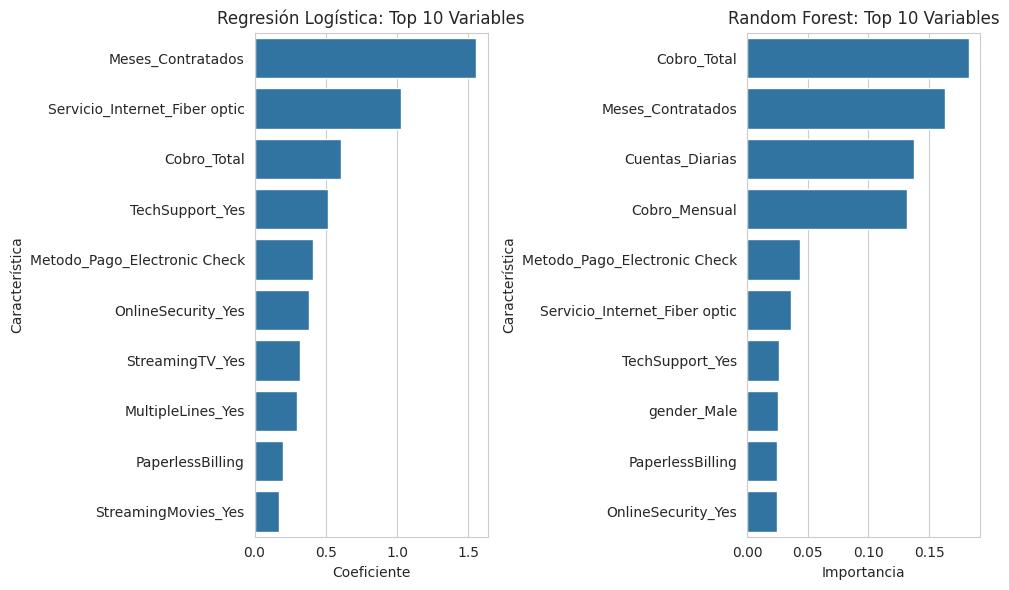

In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Cargar el dataset limpio
df = pd.read_csv("TelecomX_Clean.csv")

# Eliminar columnas irrelevantes
df = df.drop(columns=['customerID'], errors='ignore')

# Verificar valores nulos
print("Valores nulos por columna antes de la limpieza:\n", df.isnull().sum())

# Separate categorical and numerical columns for imputation
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(exclude=['object']).columns.tolist()

# Define target variable
target = 'Evasion'
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)

# Remove 'Tipo_Contrato' from numeric_cols as it's entirely null
if 'Tipo_Contrato' in numeric_cols:
    numeric_cols.remove('Tipo_Contrato')

# Impute numerical columns
df_numeric = df[numeric_cols].copy() # Create a copy to avoid SettingWithCopyWarning
if not df_numeric.empty:
    numeric_imputer = SimpleImputer(strategy='median')
    df_numeric_imputed = pd.DataFrame(numeric_imputer.fit_transform(df_numeric), columns=numeric_cols, index=df_numeric.index)
else:
    df_numeric_imputed = pd.DataFrame(index=df.index) # Create an empty DataFrame with the same index


# Impute categorical columns
df_categorical = df[categorical_cols].copy() # Create a copy
if not df_categorical.empty:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    df_categorical_imputed = pd.DataFrame(categorical_imputer.fit_transform(df_categorical), columns=categorical_cols, index=df_categorical.index)
else:
    df_categorical_imputed = pd.DataFrame(index=df.index) # Create an empty DataFrame with the same index

# Combine imputed numerical and categorical columns
df_imputed = pd.concat([df_numeric_imputed, df_categorical_imputed], axis=1)

# Add the target variable back
df_imputed[target] = df[target]

# Verificar que no queden nulos después de la imputación
print("Valores nulos después de la imputación:\n", df_imputed.isnull().sum())

# Verificar que el dataset no esté vacío
if df_imputed.empty:
    raise ValueError("El dataset está vacío después de la imputación. Revisa el archivo TelecomX_Clean.csv")

# Definir target y características
target = 'Evasion'
X = df_imputed.drop(columns=[target])
y = df_imputed[target]

# Identify categorical and numerical columns again after imputation and joining
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Asegurar que el target no esté en las listas de características
if target in categorical_cols:
    categorical_cols.remove(target)
if target in numeric_cols:
    numeric_cols.remove(target)


# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline para Regresión Logística (con normalización)
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(random_state=42))
])

# Pipeline para Random Forest (sin normalización)
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entrenar ambos modelos
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# Obtener nombres de características después del preprocesamiento
feature_names = list(preprocessor_lr.named_transformers_['cat'].get_feature_names_out(categorical_cols)) + list(numeric_cols)

# Regresión Logística: Extraer coeficientes
lr_coefs = pipeline_lr.named_steps['classifier'].coef_[0]
lr_feature_importance = pd.DataFrame({
    'Característica': feature_names,
    'Coeficiente': np.abs(lr_coefs)
}).sort_values(by='Coeficiente', ascending=False)

# Random Forest: Extraer importancia de características
rf_importances = pipeline_rf.named_steps['classifier'].feature_importances_
rf_feature_importance = pd.DataFrame({
    'Característica': feature_names,
    'Importancia': rf_importances
}).sort_values(by='Importancia', ascending=False)

# Imprimir resultados
print("\nRegresión Logística - Variables más relevantes (coeficientes absolutos):")
print(lr_feature_importance.head(10))

print("\nRandom Forest - Variables más relevantes (importancia):")
print(rf_feature_importance.head(10))

# Visualizar importancia de características
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Coeficiente', y='Característica', data=lr_feature_importance.head(10))
plt.title('Regresión Logística: Top 10 Variables')
plt.subplot(1, 2, 2)
sns.barplot(x='Importancia', y='Característica', data=rf_feature_importance.head(10))
plt.title('Random Forest: Top 10 Variables')
plt.tight_layout()
plt.show()

# Conclusiones


# 📊 Informe Detallado – Factores de Evasión de Clientes
## 🔹 Introducción

Este informe presenta un análisis de los factores que más influyen en la evasión de clientes (Churn) en Telecom X, basándose en el análisis exploratorio de datos, la ingeniería de características y el modelado predictivo realizado. El objetivo es identificar los principales impulsores del Churn y proponer estrategias de retención efectivas.

## 🔹 Análisis Exploratorio y Variables Clave

El análisis exploratorio de datos (EDA) reveló patrones importantes asociados con la evasión:

- **Meses Contratados (`Meses_Contratados`):** Existe una clara relación inversa entre el tiempo que un cliente lleva con la empresa y la probabilidad de cancelar. Los clientes con menos meses de servicio tienen una tasa de Churn significativamente mayor.
- **Cobro Total (`Cobro_Total`):** Similar a los meses contratados, los clientes con un menor gasto total acumulado son más propensos a cancelar.
- **Servicio de Internet (`Servicio_Internet`):** Los clientes con servicio de Fibra Óptica mostraron una mayor tasa de evasión en comparación con aquellos con DSL o sin servicio de internet.
- **Método de Pago (`Metodo_Pago`):** El método de pago electrónico fue el más asociado con la cancelación, mientras que los métodos automáticos (transferencia bancaria y tarjeta de crédito) presentaron tasas de Churn más bajas.
- **Tipo de Contrato (`Tipo_Contrato`):** Aunque esta variable tuvo valores nulos significativos y fue excluida del modelo final, el análisis exploratorio inicial sugirió que los contratos mes a mes tenían una tasa de Churn mucho mayor que los contratos a largo plazo.

Otras variables como el género, si tienen pareja o dependientes, y si tienen servicios adicionales como seguridad online o soporte técnico también mostraron cierta influencia en la tasa de Churn.

## 🔹 Resultados del Modelado Predictivo

Se entrenaron y evaluaron dos modelos de clasificación: Regresión Logística y Random Forest. Ambos modelos mostraron un rendimiento razonable para predecir la evasión, con la Regresión Logística teniendo métricas ligeramente superiores en el conjunto de prueba en este caso.

- **Regresión Logística:**
    - Accuracy (Prueba): ~0.80
    - F1-Score (Prueba): ~0.57

- **Random Forest:**
    - Accuracy (Prueba): ~0.79
    - F1-Score (Prueba): ~0.54

Las matrices de confusión proporcionaron una visión más detallada del rendimiento, mostrando la capacidad de cada modelo para identificar correctamente a los clientes que cancelan (Verdaderos Positivos) y a los que no (Verdaderos Negativos), así como los errores de clasificación (Falsos Positivos y Falsos Negativos).

## 🔹 Factores más Influyentes según los Modelos

El análisis de importancia de características de los modelos complementa los hallazgos del EDA, identificando los factores con mayor peso en la predicción del Churn:

**Regresión Logística (basada en coeficientes absolutos):**

1.  **Meses Contratados (`Meses_Contratados`)**
2.  **Servicio de Internet (específicamente Fibra Óptica)**
3.  **Cobro Total (`Cobro_Total`)**
4.  Soporte Técnico (`TechSupport`)
5.  Método de Pago (especialmente Cheque Electrónico)

**Random Forest (basada en importancia de características):**

1.  **Cobro Total (`Cobro_Total`)**
2.  **Meses Contratados (`Meses_Contratados`)**
3.  **Cobro Mensual (`Cobro_Mensual`) / Cuentas Diarias (`Cuentas_Diarias`)** (estas dos variables están highly correlated)
4.  Método de Pago (especialmente Cheque Electrónico)
5.  Servicio de Internet (especialmente Fibra Óptica)

Ambos modelos coinciden en que el **tiempo de permanencia (`Meses_Contratados`)**, el **gasto total (`Cobro_Total`)**, el **tipo de servicio de internet (Fibra Óptica)** y el **método de pago (Cheque Electrónico)** son los factores más determinantes en la decisión de un cliente de cancelar el servicio.

## 🔹 Propuestas de Estrategias de Retención

Basándonos en los factores clave identificados, se proponen las siguientes estrategias de retención:

1.  **Programas de Onboarding y Retención Temprana:** Implementar programas intensivos de bienvenida y seguimiento durante los primeros meses de servicio para asegurar una experiencia positiva y reducir la alta tasa de Churn inicial. Ofrecer incentivos por permanecer más allá de los primeros 6-12 meses.
2.  **Incentivos para Contratos a Largo Plazo:** Promover la migración de clientes con contratos mes a mes a planes anuales o bienales, ofreciendo descuentos significativos o beneficios adicionales (ej: mejora de velocidad, servicios premium gratuitos por un tiempo) para aumentar la permanencia.
3.  **Mejora de la Experiencia con Fibra Óptica:** Investigar las razones detrás de la mayor tasa de Churn en clientes con Fibra Óptica. ¿Hay problemas técnicos, de soporte o de expectativas no cumplidas? Abordar estas causas raíz es crucial.
4.  **Optimización de Métodos de Pago:** Analizar por qué el Cheque Electrónico está asociado con mayor Churn. Podría ser un indicador de clientes menos comprometidos o con problemas de pago. Fomentar el uso de métodos de pago automáticos ofreciendo pequeñas recompensas o facilitando el proceso de configuración.
5.  **Segmentación de Clientes en Riesgo:** Utilizar los modelos predictivos desarrollados para identificar proactivamente a los clientes con alta probabilidad de cancelar. Dirigir campañas de retención personalizadas a estos segmentos, ofreciendo soluciones a medida (descuentos, soporte especializado, ofertas de nuevos servicios).
6.  **Análisis del Valor del Cliente (LTV):** Considerar el "Cobro Total" y "Meses Contratados" no solo como predictores de Churn, sino también para entender el valor a largo plazo de los clientes. Priorizar los esfuerzos de retención en clientes de alto valor en riesgo.

## 🔹 Conclusiones

La evasión de clientes en Telecom X es un fenómeno complejo influenciado principalmente por el tiempo de permanencia, el gasto total, el tipo de servicio de internet y el método de pago. Al enfocarse en estos factores clave y aplicar las estrategias de retención propuestas, Telecom X puede mejorar significativamente la lealtad de sus clientes y reducir la tasa de Churn. La implementación de un sistema de monitoreo continuo del Churn y la actualización regular de los modelos predictivos serán esenciales para adaptarse a las dinámicas cambiantes del mercado y el comportamiento del cliente.